# Proximal Method for Constrained Minimization in 2D

**Author:** Leonardo Rossi


## Introduction

This notebook is part of the project for the PhD course **Proximal Methods in Numerical Optimization** held by PhD Andrea De Marchi at the University of Trento.

The goal of this assignment is to implement a proximal method to solve a constrained optimization problem in two dimensions. In this notebook, the **Projected Gradient Descent** method is implemented and tested on two classical benchmark functions -**Himmelblau** and **Three Hump Camel**- subject to **disk constrained set**.


## Constrained Minimization

Structured optimization problems are expressed in **composite form**:

$$\min_{x \in \mathbb{R}^n} \varphi(x) := f(x) + g(x)$$

where $f$ is a **smooth function** (differentiable, with Lipschitz gradient) and $g$ is **possibly nonsmooth**, often encoding structure such as regularization or constraints.

**Constrained optimization is a special case of this framework.** The feasible set $C$ can be encoded through the **indicator function**:

$$\delta_C(x) = \begin{cases} 0 & x \in C \\ +\infty & x \notin C \end{cases}$$

By setting $g = \delta_C$, the constrained problem $\min_{x \in C} f(x)$ is equivalently reformulated as the unconstrained composite problem:

$$\min_{x \in \mathbb{R}^n} f(x) + \delta_C(x)$$

This perspective allows constrained minimization to be solved using the same proximal methods developed for general structured optimization, with the projection operator coinciding with the proximal operator.

## Setup and Main Imports

This notebook uses **JAX** for automatic differentiation and numerical computations, along with **NumPy** for array manipulation.

In [1]:
import jax
import numpy as np
import jax.numpy as jnp

## Test Functions

This section defines a `TestFunction` dataclass to represent benchmark optimization functions. Each test function includes the objective to minimize, the search domain bounds, and the known global minima coordinates. 

Booth and Beale functions are classic multimodal benchmarks commonly used to evaluate optimization algorithms. The mathematical formulation of each function, its global minima, and typical search domain are taken from literature.

In [2]:
from dataclasses import dataclass
from typing import Callable

@dataclass(frozen=True)
class TestFunction:
    """
    Representation of a benchmark function
    used to test optimization algorithms.

    This class stores a callable objective
    function together with metadata describing
    its search domain and the coordinates of 
    its known global minima.

    :param fn: Objective function to minimize
    :type fn: Callable
    :param search_domain: Bounds for each dimension of the search space
    :type search_domain: tuple[tuple[float, float], ...]
    :param global_minima: Global minima coordinates
    :type global_minima: tuple[tuple[float, ...], ...]
    """

    fn: Callable
    search_domain: tuple[tuple[float, float], ...]
    global_minima: tuple[tuple[float, ...], ...]

    def value(self, z: jax.Array) -> jax.Array:
        """
        Evaluate the value of the
        test function at point z.

        :param z: Input vector
        :type z: jax.Array
        :return: Function value at z
        :rtype: jax.Array
        """
        return self.fn(z)


    def gradient(self, z: jax.Array) -> jax.Array:
        """
        Evaluate the gradient of the
        test function at point z.

        :param z: Input vector
        :type z: jax.Array
        :return: Gradient at z
        :rtype: jax.Array
        """
        return jax.grad(self.fn)(z)

In [3]:
def himmelblau(z):
    """
    Evaluate Himmelblau's function at point z.

    :param z: Input vector.
    :type z: jax.Array
    :return: Function value at z.
    :rtype: jax.Array
    """
    x, y = z
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2


Himmelblau = TestFunction(
    fn = himmelblau,
    search_domain = ((-5.0, 5.0), (-5.0, 5.0)),
    global_minima = (
        (3.0, 2.0),
        (-2.805118, 3.131312),
        (-3.779310, -3.283186),
        (3.584428, -1.848126),
    )
)

In [4]:
def three_hump_camel(z):
    """
    Evaluate Three-Hump Camel function at point z.

    :param z: Input vector.
    :type z: jax.Array
    :return: Function value at z.
    :rtype: jax.Array
    """
    x, y = z
    return 2*x**2 - 1.05*x**4 + (x**6)/6 + x*y + y**2


ThreeHumpCamel = TestFunction(
    fn = three_hump_camel,
    search_domain = ((-5.0, 5.0), (-5.0, 5.0)),
    global_minima = ((0.0, 0.0),)
)


## Constraint sets

This section defines constraint sets used in projected optimization methods. Each constraint is represented by an abstract base class `ConstraintSet` that requires subclasses to implement a `project` method.

In general, the projection operator $\Pi_C(z)$ maps any point $z \in \mathbb{R}^n$ onto the closest point in the feasible set $C$:

$$\Pi_C(z) = \arg\min_{x \in C} \|x - z\|_2$$

In [5]:
from abc import ABC, abstractmethod
from dataclasses import dataclass

class ConstraintSet(ABC):
    """
    Abstract base class for constraint sets used in optimization.

    A constraint defines a feasible set together with a projection
    operator that maps any point onto that set. Subclasses must
    implement the :meth:`project` method.
    """

    @abstractmethod
    def project(self, z: jax.Array) -> jax.Array:
        """
        Project a point onto the constraint set.

        :param z: Point to be projected.
        :type z: jax.Array
        :return: Projected point lying in the constraint set.
        :rtype: jax.Array
        :raises NotImplementedError: If the method is not implemented
            in a subclass.
        """
        raise NotImplementedError

### Disk Constraint

In this notebook, the disk constraint defines a feasible set as a closed Euclidean disk centered at a point $c \in \mathbb{R}^2$ with radius $r$:

$$C = \{z \in \mathbb{R}^2 : \|z - c\|_2 \leq r\}$$

The projection of a point $z$ onto this set has a closed-form solution:

$$\Pi_C(z) = \begin{cases} z & \text{if } \|z - c\|_2 \leq r \\ c + \frac{r}{\|z - c\|_2} (z-c) &  \end{cases}$$

Or, equivalently:

$$\Pi_C(z) = c + \min\left\{1, \frac{r}{\|z - c\|_2}\right\} (z-c)$$


If the point lies inside the disk, it is returned unchanged. Otherwise, it is scaled back to the boundary along the radial direction from the center.


In [6]:
from dataclasses import field

@dataclass(frozen=True)
class DiskConstraintSet2D(ConstraintSet):
    """
    Constraint set representing a Euclidean disk in 2D.
    

    :param radius: Radius of the disk.
    :type radius: float
    :param center: Center of the disk.
    :type center: jax.Array
    """

    disk_radius: float = 1.0
    disk_center: jax.Array = field(default_factory=lambda: jnp.zeros(2))

    def project(self, z: jax.Array) -> jax.Array:
        """
        Project a vector onto the disk constraint set.

        If the vector lies outside the disk, it is scaled back
        to the boundary along the radial direction from the center.
        Otherwise, it is returned unchanged.

        :param z: Input vector.
        :type z: jax.Array
        :return: Projected vector whose norm is at most ``disk_radius``.
        :rtype: jax.Array
        """

        dist = jnp.linalg.norm(z - self.disk_center)
        scale = jnp.minimum(1.0, self.disk_radius / (dist + 1e-12))
        z_proj = self.disk_center + scale * (z - self.disk_center)

        return z_proj

## Projected Gradient Descent Solver

The **Proximal Gradient Method** extends gradient descent to composite problems by minimizing, at each step, a quadratic approximation of $f$ together with the nonsmooth term $g$:

$$x_{k+1} = \operatorname{prox}_{\alpha g}(x_k - \alpha \nabla f(x_k))$$

where the **proximal operator** is formally defined as:

$$\operatorname{prox}_{\alpha g}(z) = \arg\min_u \left( g(u) + \frac{1}{2\alpha}\|u - z\|^2 \right)$$

When $g = \delta_C$, the proximal operator coincides with the **Euclidean projection** onto $C$. In this case, the proximal gradient method reduces to **Projected Gradient Descent (PGD)**:

$$x_{k+1} = \operatorname{proj}_C(x_k - \alpha_k \nabla f(x_k))$$

Each iteration can be interpreted as two half-steps:
- **Explicit step:** move along the negative gradient of the smooth component $f$
- **Implicit step:** enforce feasibility by projecting onto $C$

### Backtracking Line Search

The step size $\alpha_k$ can be adaptively selected using **backtracking line search**. Starting from an initial value $\alpha$, the step size is repeatedly reduced by a factor $\beta \in (0, 1)$ until the following **sufficient decrease condition** is satisfied:

$$f(x^+) \leq f(x_k) + \nabla f(x_k)^\top (x^+ - x_k) + \frac{1}{2\alpha} \|x^+ - x_k\|_2^2$$

where $x^+ = \operatorname{proj}_C(x_k - \alpha \nabla f(x_k))$ is the candidate next iterate. This condition guarantees that the objective value decreases by at least the amount predicted by a local quadratic model, ensuring convergence of the algorithm.

In [7]:
class ProjectedGradientDescent:
    """
    Projected gradient descent solver for constrained optimization problems.
    This optimizer minimizes an objective function over a feasible set by
    combining gradient steps with projection onto the constraint set.
    A backtracking line search is used to adapt the step size.
    """

    def __init__(self, alpha: float =0.01, max_iter: int =10000, tol: float =1e-6, max_backtracking_steps: int =50):
        """
        Initialize the projected gradient descent solver.

        :param alpha: Initial step size used in the line search.
        :type alpha: float
        :param max_iter: Maximum number of optimization iterations.
        :type max_iter: int
        :param tol: Stopping tolerance
        :type tol: float
        :param max_backtracking_steps: Maximum number of backtracking reductions.
        :type max_backtracking_steps: int
        """
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol
        self.max_backtracking_steps = max_backtracking_steps


    def back_tracking_line_search(self, func: TestFunction, constraint: ConstraintSet, z: jax.Array, grad: jax.Array, beta: float =0.5):
        """
        Perform backtracking line search for a projected gradient step.

        Starting from the current step size, this method
        repeatedly reduces the step size by a factor until the
        sufficient decrease condition is satisfied or the maximum 
        number of backtracking steps is reached.

        :param func: Objective function to minimize.
        :type func: TestFunction
        :param constraint: Constraint set with projection operator.
        :type constraint: ConstraintSet
        :param z: Current iterate.
        :type z: jax.Array
        :param grad: Gradient of the objective.
        :type grad: jax.Array
        :param beta: Multiplicative reduction factor for the step size.
        :type beta: float
        :return: Accepted step size and projected next iterate.
        :rtype: tuple[float, jax.Array]
        """

        # Get current step size
        alpha = self.alpha
        
        fz = func.value(z)

        for _ in range(self.max_backtracking_steps):

            # Compute the projected gradient step
            z_new = constraint.project(z - alpha * grad)
            diff = z_new - z

            # Compute the quadratic approximation of the objective
            q = fz + jnp.dot(grad, diff) + (jnp.dot(diff, diff) / (2.0 * alpha))
            
            # If the sufficient decrease condition is satisfied:
            if func.value(z_new) <= q:

                # Update current step size and new point
                self.alpha = alpha
                return alpha, z_new
            
            # Otherwise reduce the step size
            alpha *= beta
        
        z_new = constraint.project(z - alpha * grad)
        self.alpha = alpha
        
        return alpha, z_new


    def solve(self, func: TestFunction, constraint: ConstraintSet, z_init: jax.Array, use_back_tracking_line_search: bool =True):
        """
        Solve the constrained optimization problem.

        The initial point is first projected onto the feasible set. At each
        iteration, a projected gradient step is computed using backtracking
        line search. The method stops when the distance between consecutive
        iterates falls below the specified tolerance or when the maximum
        number of iterations is reached.
    
        :param func: Objective function to minimize.
        :type func: TestFunction
        :param constraint: Constraint set.
        :type constraint: ConstraintSet
        :param z_init: Initial point.
        :type z_init: jax.Array
        :param use_back_tracking_line_search: Whether to use backtracking line search (default: True).
        :type use_back_tracking_line_search: bool
        :return: Final iterate and optimization history.
        :rtype: tuple[jax.Array, jax.Array]
        """

        # To store the optimization history (for visualization)
        history = [z_init]

        # Project the initial point onto the constraint set
        z = constraint.project(z_init)

        history.append(z)

        for _ in range(self.max_iter):

            if use_back_tracking_line_search:
                _, z_new = self.back_tracking_line_search(func, constraint, z, func.gradient(z))
            else:
                z_new = constraint.project(z - self.alpha * func.gradient(z))

            # Check for convergence
            if jnp.linalg.norm(z_new - z) < self.tol:
                z = z_new
                history.append(z)
                break

            # Update
            z = z_new
            history.append(z)
        
        return z, jnp.stack(history)

## Visualization

The following function visualizes the optimization trajectory over the objective function's contour plot. It displays the constraint set boundary, the randomly generated intial point and its projection to the feasible set, the final solution, and the known global minima.

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_optimization(func: TestFunction, constraint: ConstraintSet, history: jax.Array):
    """
    Visualize the optimization trajectory over the objective function contour plot.

    :param func: Test function to visualize.
    :param constraint: Constraint set.
    :param history: Array of iterates from the optimization.
    :return: Figure and axes objects.
    """

    xlim = func.search_domain[0]
    ylim = func.search_domain[1]

    xs = jnp.linspace(*xlim, 100)
    ys = jnp.linspace(*ylim, 100)

    # Create a grid of points over the search domain
    x_jnp, y_jnp = jnp.meshgrid(xs, ys)
    grid_jnp = jnp.stack([x_jnp, y_jnp], axis=-1)

    # Evaluate the function on the grid using JAX's vectorization
    z_jnp = jax.vmap(jax.vmap(func.value))(grid_jnp)

    # Convert JAX arrays to NumPy for plotting
    x_np = np.array(x_jnp) 
    y_np = np.array(y_jnp)
    z_np = np.array(z_jnp)

    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot the objective function level curves
    contour = ax.contourf(x_np, y_np, z_np, levels=50, alpha=0.8)
    ax.contour(x_np, y_np, z_np, levels=50, colors=[(1,1,1)], linewidths=0.3, alpha=0.5)
    plt.colorbar(contour, ax=ax, label="f(x, y)")

    # Plot the constraint set boundary
    patch = Circle(constraint.disk_center, constraint.disk_radius, fill=False, linewidth=2.5, 
                   edgecolor=(0.99, 0.99, 0.99), linestyle=(0, (5, 3)), label="Constraint Set Boundary")
    ax.add_patch(patch)

    # Plot the optimization trajectory and key points
    history_np = np.array(history)
    ax.plot(history_np[:, 0], history_np[:, 1], color=(1,0,0), linestyle="-", 
            marker=".", linewidth=1.5, markersize=4, zorder=5, label="Optimization Trajectory")

    ax.scatter(*history_np[0], c=[(1,0,0)], s=100, zorder=6, marker="s",
               edgecolors=[(1,0,0)], linewidths=1.5, label="Initial Point")
    
    ax.scatter(*history_np[1], c=[(1,0,0)], s=100, zorder=6, marker="o",
               edgecolors=[(1,0,0)], linewidths=1.5, label="Initial Projection")

    ax.scatter(*history_np[-1], c=[(1,0,0)], s=150, marker="*", zorder=8, 
               edgecolors=[(1,0,0)], linewidths=1.5, label="PGD Solution")
    
    # Plot the known global minima
    minima = np.array(func.global_minima)
    ax.scatter(minima[:, 0], minima[:, 1], c=[(0.99, 0.99, 0.99)], s=200, marker="X", 
               zorder=7, edgecolors=[(0.99, 0.99, 0.99)], linewidths=0.5, label="Global Minimum")
     
    ax.set(xlim=xlim, ylim=ylim, xlabel="x", ylabel="y", aspect="equal")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    return fig, ax

## Tests

This section demonstrates the Projected Gradient Descent algorithm on the Himmelblau and Three Hump Camel benchmark functions, both constrained to a unit disk centered at the origin. The optimization starts from a random initial point within the search domain.

### Himmelblau Function with Disk Constraint

In [9]:
disk_constraint = DiskConstraintSet2D()
solver = ProjectedGradientDescent(alpha=0.1, max_iter=1000, tol=1e-8)

bounds = jnp.array(Himmelblau.search_domain)

# Set random seed for reproducibility
key = jax.random.PRNGKey(42)

# Sample a random initial point within the search domain
z_init = jax.random.uniform(key, shape=(2,), minval=bounds[:, 0], maxval=bounds[:, 1])

solution, history= solver.solve(Himmelblau, disk_constraint, z_init)

print(f"Initial point: {z_init}")
print(f"Solution: {solution}")
print(f"Function value at solution: {Himmelblau.value(solution):.6f}")
print(f"Number of iterations: {len(history) - 1}")

Initial point: [-0.11290431  1.7979717 ]
Solution: [0.77347994 0.63382083]
Function value at solution: 129.340210
Number of iterations: 30


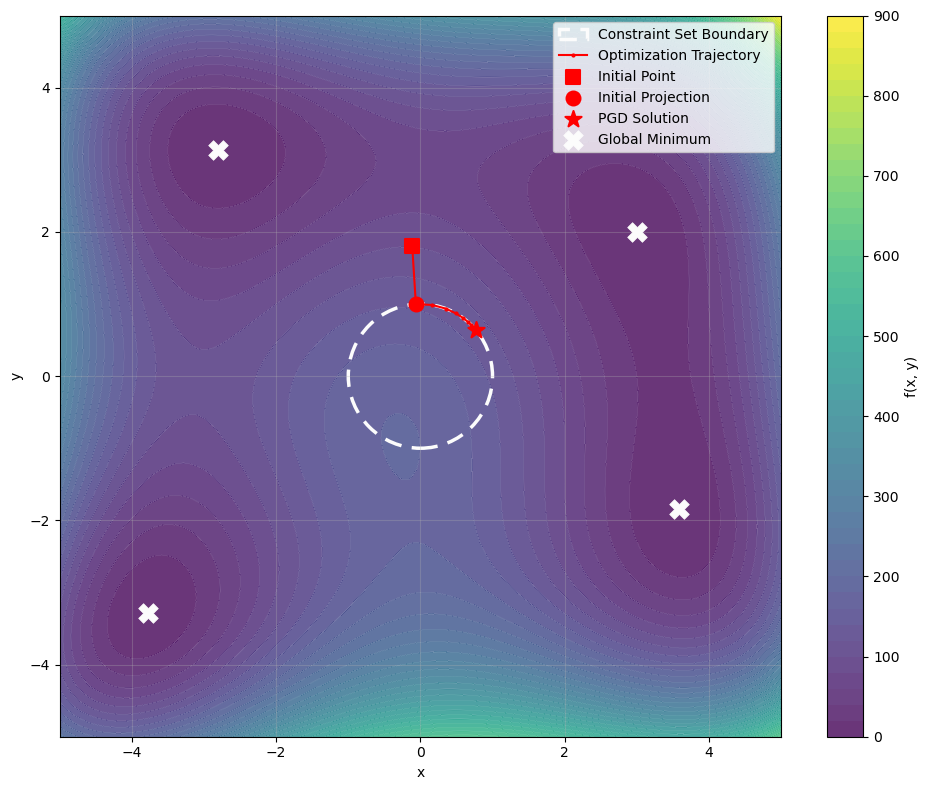

In [10]:
plot_optimization(Himmelblau, disk_constraint, history)
plt.show()

### Three Hump Camel Function with Disk Constraint

In [11]:
disk_constraint_set = DiskConstraintSet2D()
bounds = jnp.array(ThreeHumpCamel.search_domain)
solver = ProjectedGradientDescent(alpha=0.1, max_iter=1000, tol=1e-8)

# Set random seed for reproducibility
key = jax.random.PRNGKey(123)

# Sample a random initial point within the search domain
z_init = jax.random.uniform(key, shape=(2,), minval=bounds[:, 0], maxval=bounds[:, 1])

solution, history = solver.solve(ThreeHumpCamel, disk_constraint_set, z_init)

print(f"Initial point: {z_init}")
print(f"Solution: {solution}")
print(f"Function value at solution: {ThreeHumpCamel.value(solution):.6f}")
print(f"Number of iterations: {len(history) - 1}")

Initial point: [4.4907465 2.9977262]
Solution: [-1.8495953e-08  4.4653181e-08]
Function value at solution: 0.000000
Number of iterations: 74


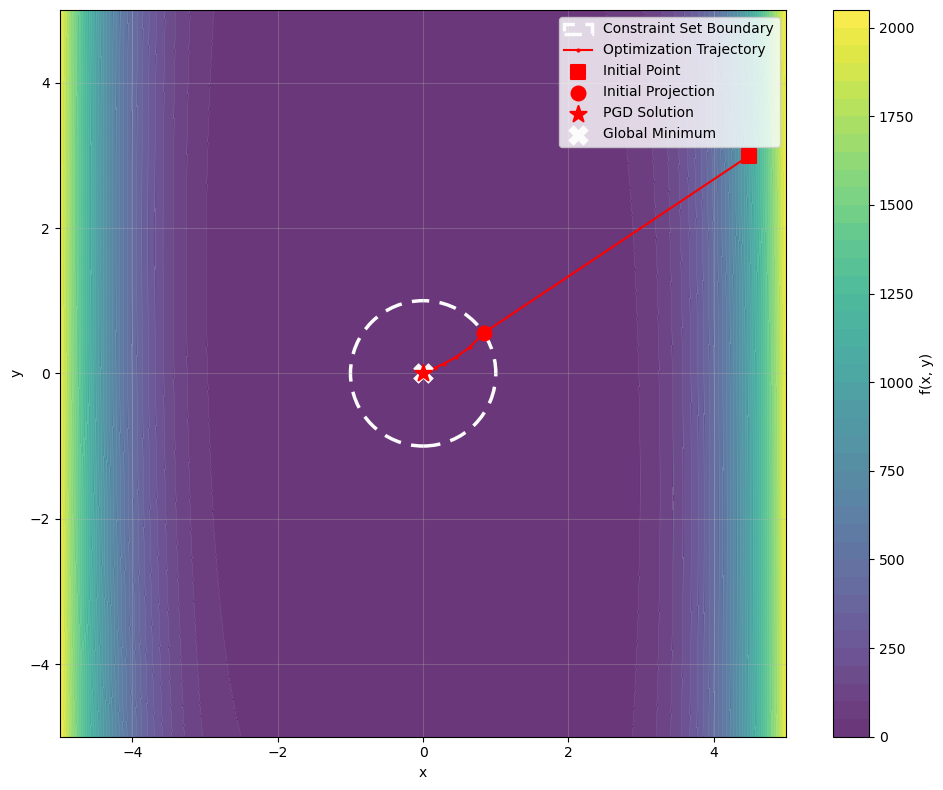

In [12]:
plot_optimization(ThreeHumpCamel, disk_constraint, history)
plt.show()